# PM2.5 Forecasting — SARIMAX Model

**Project:** DSA SCI 8001 Time Series Analysis — Final Project  
**Input:** `la_daily_2017_2023_clean.csv`  
**Task:** Multi-step ahead forecasting of daily PM2.5  
**Model:** SARIMAX(1,0,1)(1,0,1,7) with exogenous variables (humidity, temperature)

---

## Model Design

**SARIMAX(p,d,q)(P,D,Q,s)** extends ARIMA with:
- **Seasonal component (s=7):** captures weekly periodicity in PM2.5 (weekday vs weekend traffic and industrial activity patterns)
- **Exogenous variables (X):** humidity and temperature as meteorological regressors

The model is fitted once on the combined train+validation set (2017–2021), then used to forecast the entire test period (2022) directly.

---

## Data Split

| Split | Period | Days |
|-------|--------|------|
| Train | 2017-01-01 – 2020-12-31 | 1461 |
| Validation | 2021-01-01 – 2021-12-31 | 365 |
| Test | 2022-01-01 – 2022-12-31 | 365 |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

DATA_PATH  = "/Users/wanxinli/Desktop/pm2.5/final_project/data/la_daily_2017_2023_clean.csv"
OUTPUT_DIR = "/Users/wanxinli/Desktop/pm2.5/final_project/data/"

ORDER          = (1, 0, 1)      # (p, d, q)
SEASONAL_ORDER = (1, 0, 1, 7)   # (P, D, Q, s=7 weekly seasonality)
EXOG_COLS      = ["humidity", "temperature"]

df = pd.read_csv(DATA_PATH, index_col="date", parse_dates=True)

train_df    = df[df.index < "2021-01-01"]
val_df      = df[(df.index >= "2021-01-01") & (df.index < "2022-01-01")]
test_df     = df[(df.index >= "2022-01-01") & (df.index < "2023-01-01")]
train_val_df = pd.concat([train_df, val_df])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 1461 | Val: 365 | Test: 365


---
## 1. Stationarity Check (ADF Test)

ARIMA requires the target series to be stationary. We apply the **Augmented Dickey-Fuller (ADF) test**:
- H₀: series has a unit root (non-stationary)
- p-value < 0.05 → reject H₀ → series is stationary → set d=0

In [2]:
result = adfuller(train_df["pm25_cf_1"].dropna())
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
for key, val in result[4].items():
    print(f"  Critical Value {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n→ Series is STATIONARY (p < 0.05). Use d=0.")
else:
    print("\n→ Series is NON-STATIONARY. Consider d=1.")

ADF Statistic : -8.1760
p-value       : 0.0000
  Critical Value 1%: -3.4349
  Critical Value 5%: -2.8635
  Critical Value 10%: -2.5678

→ Series is STATIONARY (p < 0.05). Use d=0.


---
## 2. ACF / PACF Analysis

ACF and PACF plots guide the selection of AR and MA orders:
- **PACF** significant lags → AR order p
- **ACF** significant lags → MA order q

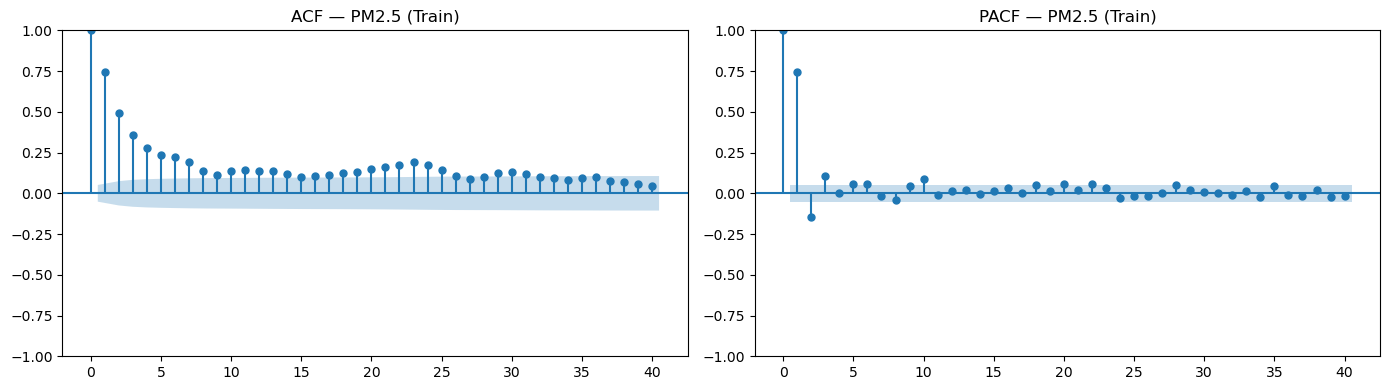

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( train_df["pm25_cf_1"], lags=40, ax=axes[0], title="ACF — PM2.5 (Train)")
plot_pacf(train_df["pm25_cf_1"], lags=40, ax=axes[1], title="PACF — PM2.5 (Train)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_sarimax_acf_pacf.png", dpi=150)
plt.show()

---
## 3. ARIMA(1,0,1) Baseline

Before fitting SARIMAX, we establish an **ARIMA(1,0,1) baseline** — same order but without seasonal component or exogenous variables. This lets us quantify the marginal gain from adding seasonality and meteorological regressors.


In [4]:
from statsmodels.tsa.arima.model import ARIMA

print("Fitting ARIMA(1,0,1) baseline on train+val (2017–2021)...")

test_actual = test_df["pm25_cf_1"].values

arima_model = ARIMA(train_val_df["pm25_cf_1"], order=(1, 0, 1))
arima_fit   = arima_model.fit()

# Forecast test period (no exog)
arima_forecast = arima_fit.forecast(steps=len(test_df))
arima_preds    = np.clip(arima_forecast.values, 0, None)

arima_mae  = mean_absolute_error(test_actual, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test_actual, arima_preds))
arima_mape = np.mean(np.abs((test_actual - arima_preds) / (test_actual + 1e-8))) * 100

# R²
ss_tot        = np.sum((test_actual - test_actual.mean())**2)
arima_r2      = 1 - np.sum((test_actual - arima_preds)**2) / ss_tot

print(f"ARIMA(1,0,1) Test Results (2022):")
print(f"  MAE  = {arima_mae:.3f} µg/m³")
print(f"  RMSE = {arima_rmse:.3f} µg/m³")
print(f"  MAPE = {arima_mape:.1f}%")
print(f"  R²   = {arima_r2:.4f}")


Fitting ARIMA(1,0,1) baseline on train+val (2017–2021)...
ARIMA(1,0,1) Test Results (2022):
  MAE  = 5.944 µg/m³
  RMSE = 6.964 µg/m³
  MAPE = 96.1%
  R²   = -0.5080


---
## 4. SARIMAX Model Fitting & Forecasting

We fit SARIMAX on the combined train+validation period (2017–2021), then forecast the entire test period (2022) in one pass. Using the full train+val history gives the model the most information before predicting unseen 2022 data.


In [5]:
print("Fitting SARIMAX on train+val (2017–2021)...")

model = SARIMAX(
    endog=train_val_df["pm25_cf_1"],
    exog=train_val_df[EXOG_COLS],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted = model.fit(disp=False)

print(fitted.summary())

Fitting SARIMAX on train+val (2017–2021)...
                                     SARIMAX Results                                     
Dep. Variable:                         pm25_cf_1   No. Observations:                 1826
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -6013.243
Date:                           Thu, 12 Mar 2026   AIC                          12040.486
Time:                                   13:21:39   BIC                          12079.021
Sample:                               01-01-2017   HQIC                         12054.704
                                    - 12-31-2021                                         
Covariance Type:                             opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
humidity        0.3344      0.023     14.290      0.000       0.289       0.

In [6]:
# Forecast test period
forecast = fitted.forecast(
    steps=len(test_df),
    exog=test_df[EXOG_COLS]
)

test_preds  = np.clip(forecast.values, 0, None)  # PM2.5 cannot be negative
#test_actual = test_df["pm25_cf_1"].values

mae  = mean_absolute_error(test_actual, test_preds)
rmse = np.sqrt(mean_squared_error(test_actual, test_preds))
mape = np.mean(np.abs((test_actual - test_preds) / (test_actual + 1e-8))) * 100

# R²
ss_tot     = np.sum((test_actual - test_actual.mean())**2)
sarimax_r2 = 1 - np.sum((test_actual - test_preds)**2) / ss_tot

print(f"Test Results (2022):")
print(f"  MAE  = {mae:.3f} µg/m³")
print(f"  RMSE = {rmse:.3f} µg/m³")
print(f"  MAPE = {mape:.1f}%")
print(f"  R²   = {sarimax_r2:.4f}")


Test Results (2022):
  MAE  = 4.922 µg/m³
  RMSE = 6.137 µg/m³
  MAPE = 76.0%
  R²   = -0.1711


---
## 5. Visualization

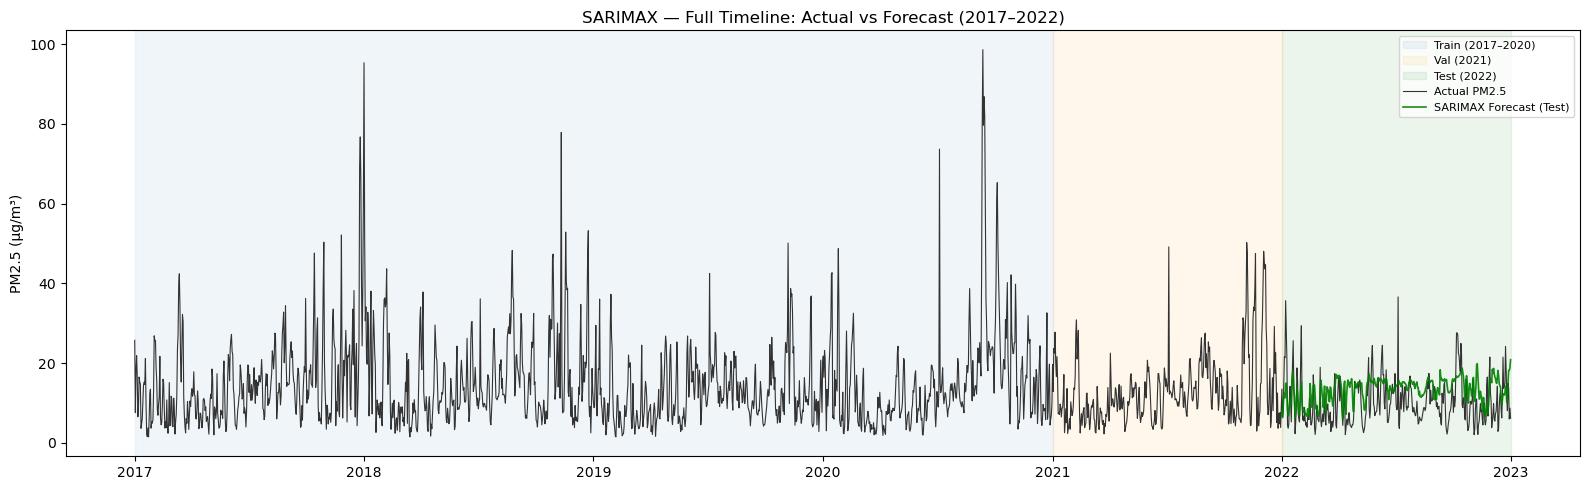

In [7]:
# Full timeline plot
full_actual = df[df.index < "2023-01-01"]

fig, ax = plt.subplots(figsize=(16, 5))

ax.axvspan(full_actual.index[0],       pd.Timestamp("2021-01-01"), alpha=0.08, color="steelblue", label="Train (2017–2020)")
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2022-01-01"), alpha=0.08, color="orange",    label="Val (2021)")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-01-01"), alpha=0.08, color="green",     label="Test (2022)")

ax.plot(full_actual.index, full_actual["pm25_cf_1"],
        color="#333333", lw=0.8, label="Actual PM2.5", zorder=2)
ax.plot(test_df.index, test_preds,
        color="green", lw=1.2, alpha=0.9, label="SARIMAX Forecast (Test)", zorder=3)

ax.set_title("SARIMAX — Full Timeline: Actual vs Forecast (2017–2022)", fontsize=12)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_sarimax_full_timeline.png", dpi=150)
plt.show()

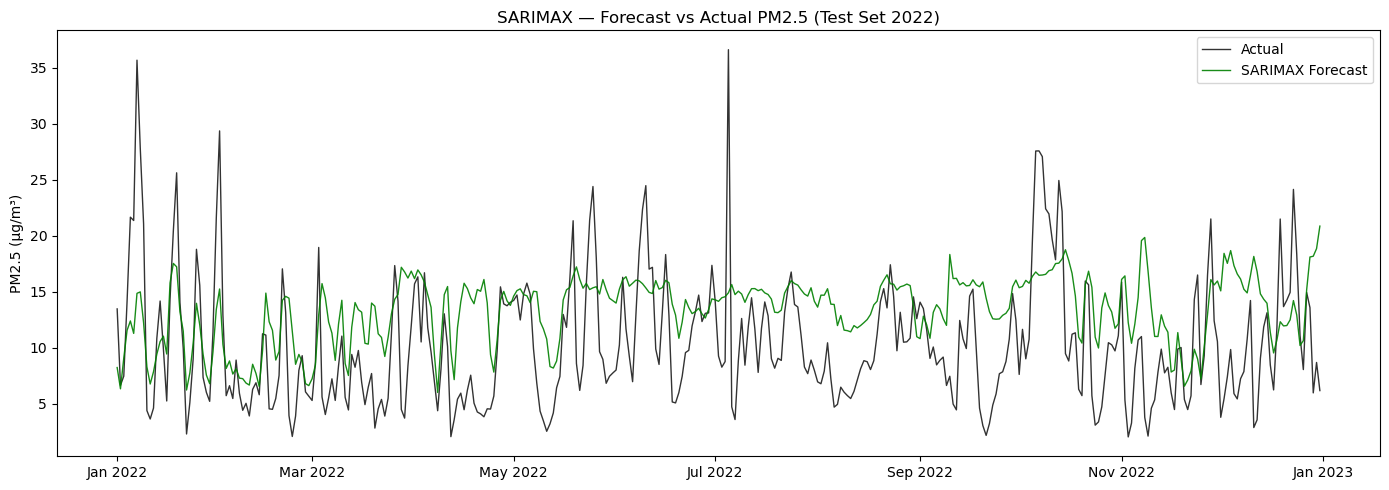

In [8]:
# Test period zoom-in
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df.index, test_actual, color="#333333", lw=1.0, label="Actual")
ax.plot(test_df.index, test_preds,  color="green",   lw=1.0, alpha=0.9, label="SARIMAX Forecast")
ax.set_title("SARIMAX — Forecast vs Actual PM2.5 (Test Set 2022)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_sarimax_forecast_test.png", dpi=150)
plt.show()

---
## 6. Residual Analysis

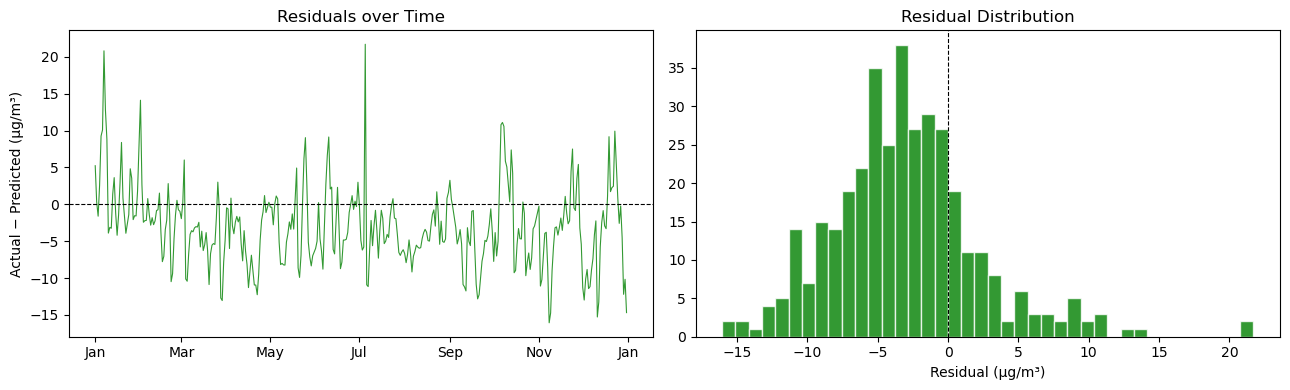

Residual mean : -3.050 µg/m³
Residual std  : 5.325 µg/m³


In [9]:
residuals = test_actual - test_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(test_df.index, residuals, color="green", lw=0.8, alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_title("Residuals over Time")
axes[0].set_ylabel("Actual − Predicted (µg/m³)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

axes[1].hist(residuals, bins=40, color="green", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (µg/m³)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_sarimax_residuals.png", dpi=150)
plt.show()

print(f"Residual mean : {residuals.mean():.3f} µg/m³")
print(f"Residual std  : {residuals.std():.3f} µg/m³")

---
## 7. Save Results

In [10]:
results = pd.DataFrame({
    "actual":    test_actual,
    "predicted": test_preds,
    "residual":  test_actual - test_preds
}, index=test_df.index)
results.index.name = "date"
results.to_csv(OUTPUT_DIR + "sarimax_test_predictions.csv")

# Also save ARIMA predictions
arima_results = pd.DataFrame({
    "actual":    test_actual,
    "predicted": arima_preds,
    "residual":  test_actual - arima_preds
}, index=test_df.index)
arima_results.index.name = "date"
arima_results.to_csv(OUTPUT_DIR + "arima_test_predictions.csv")

# Combined metrics table
metrics = pd.DataFrame([
    {"model": "ARIMA(1,0,1)",            "MAE": round(arima_mae, 3), "RMSE": round(arima_rmse, 3), "MAPE": round(arima_mape, 1), "R2": round(arima_r2, 4)},
    {"model": "SARIMAX(1,0,1)(1,0,1,7)", "MAE": round(mae, 3),       "RMSE": round(rmse, 3),       "MAPE": round(mape, 1),       "R2": round(sarimax_r2, 4)},
])
metrics.to_csv(OUTPUT_DIR + "sarimax_metrics.csv", index=False)

print("Saved: sarimax_test_predictions.csv")
print("Saved: arima_test_predictions.csv")
print("Saved: sarimax_metrics.csv")
print()
print(metrics.to_string(index=False))


Saved: sarimax_test_predictions.csv
Saved: arima_test_predictions.csv
Saved: sarimax_metrics.csv

                  model   MAE  RMSE  MAPE      R2
           ARIMA(1,0,1) 5.944 6.964  96.1 -0.5080
SARIMAX(1,0,1)(1,0,1,7) 4.922 6.137  76.0 -0.1711


---
## Summary

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Order (p,d,q) | (1,0,1) | ACF/PACF analysis; d=0 confirmed by ADF test |
| Seasonal (P,D,Q,s) | (1,0,1,7) | Weekly seasonality in PM2.5 (weekday/weekend patterns) |
| Exogenous vars | humidity, temperature | Key meteorological drivers of PM2.5 |
| Forecast strategy | Single fit on train+val, direct forecast | Computationally efficient; appropriate for project scope |
| Negative clipping | clip(0, None) | PM2.5 is physically non-negative |

Results saved to `sarimax_test_predictions.csv` for comparison with Transformer model.